In [125]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/anmolkumar/health-insurance-cross-sell-prediction/sample_submission.csv
/kaggle/input/datasets/anmolkumar/health-insurance-cross-sell-prediction/train.csv
/kaggle/input/datasets/anmolkumar/health-insurance-cross-sell-prediction/test.csv


In [126]:
train=pd.read_csv('/kaggle/input/datasets/anmolkumar/health-insurance-cross-sell-prediction/train.csv')
test=pd.read_csv('/kaggle/input/datasets/anmolkumar/health-insurance-cross-sell-prediction/test.csv')

In [128]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from imblearn.over_sampling import RandomOverSampler

In [129]:
print(train.shape)
print(test.shape)

(381109, 12)
(127037, 11)


In [130]:
print(train.isnull().sum())
print(test.isnull().sum())

id                      0
Gender                  0
Age                     0
Driving_License         0
Region_Code             0
Previously_Insured      0
Vehicle_Age             0
Vehicle_Damage          0
Annual_Premium          0
Policy_Sales_Channel    0
Vintage                 0
Response                0
dtype: int64
id                      0
Gender                  0
Age                     0
Driving_License         0
Region_Code             0
Previously_Insured      0
Vehicle_Age             0
Vehicle_Damage          0
Annual_Premium          0
Policy_Sales_Channel    0
Vintage                 0
dtype: int64


In [131]:
print(train.head)

<bound method NDFrame.head of             id  Gender  Age  Driving_License  Region_Code  Previously_Insured  \
0            1    Male   44                1         28.0                   0   
1            2    Male   76                1          3.0                   0   
2            3    Male   47                1         28.0                   0   
3            4    Male   21                1         11.0                   1   
4            5  Female   29                1         41.0                   1   
...        ...     ...  ...              ...          ...                 ...   
381104  381105    Male   74                1         26.0                   1   
381105  381106    Male   30                1         37.0                   1   
381106  381107    Male   21                1         30.0                   1   
381107  381108  Female   68                1         14.0                   0   
381108  381109    Male   46                1         29.0                   0  

In [133]:
numerical_columns=['Age','Region_Code','Annual_Premium','Policy_Sales_Channel','Vintage','Response']
categorical_columns=['Gender','Driving_License','Previously_Insured','Vehicle_Age','Vehicle_Damage']

In [134]:
train[numerical_columns].describe()

,Age,Region_Code,Annual_Premium,Policy_Sales_Channel,Vintage,Response
count,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000
mean,38.822584,26.388807,30564.389581,112.034295,154.347397,0.122563
std,15.511611,13.229888,17213.155057,54.203995,83.671304,0.327936
min,20.000000,0.000000,2630.000000,1.000000,10.000000,0.000000
25%,25.000000,15.000000,24405.000000,29.000000,82.000000,0.000000
50%,36.000000,28.000000,31669.000000,133.000000,154.000000,0.000000
75%,49.000000,35.000000,39400.000000,152.000000,227.000000,0.000000
max,85.000000,52.000000,540165.000000,163.000000,299.000000,1.000000


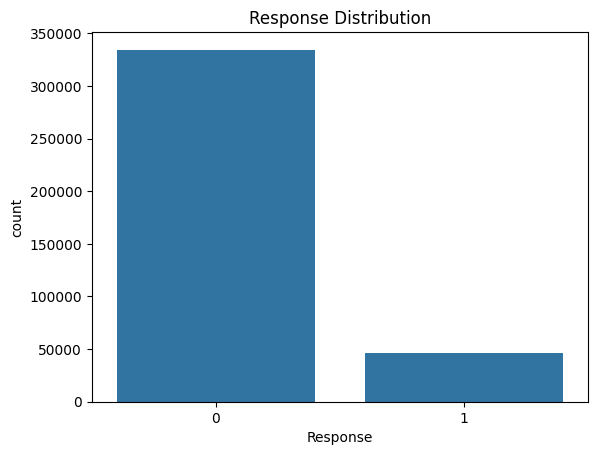

In [135]:
sns.countplot(x='Response', data=train)
plt.title("Response Distribution")
plt.show()

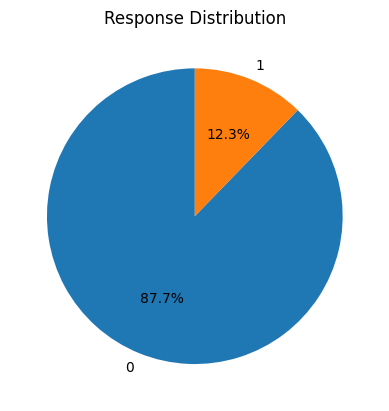

In [100]:
response_counts = train['Response'].value_counts()

plt.pie(response_counts,
        labels=response_counts.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title("Response Distribution")
plt.show()

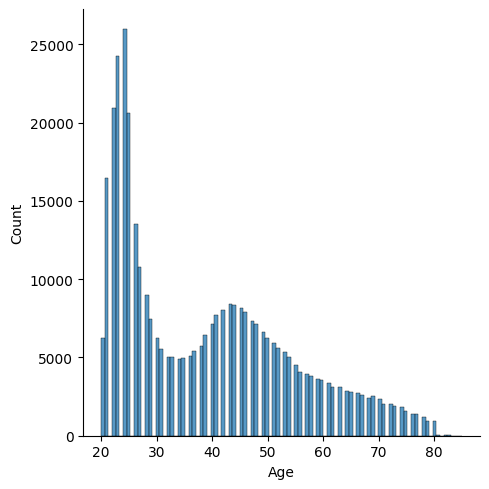

In [136]:
sns.displot(train['Age'])

<Axes: xlabel='Age', ylabel='Response'>

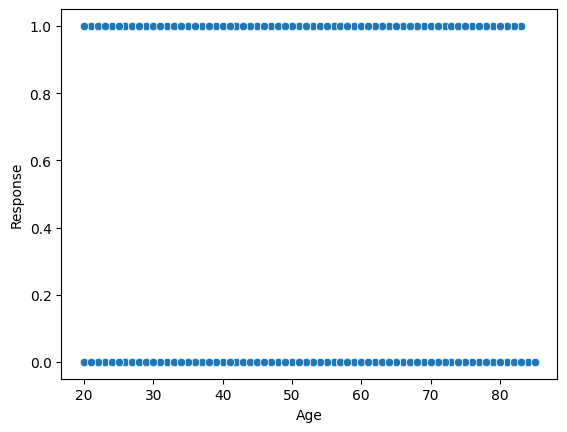

In [102]:
sns.scatterplot(x=train['Age'],y=train['Response'])

<Axes: xlabel='Age', ylabel='Annual_Premium'>

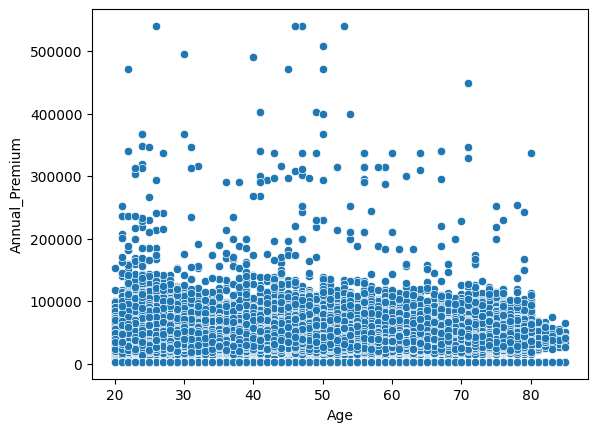

In [137]:
sns.scatterplot(x=train['Age'],y=train['Annual_Premium'])

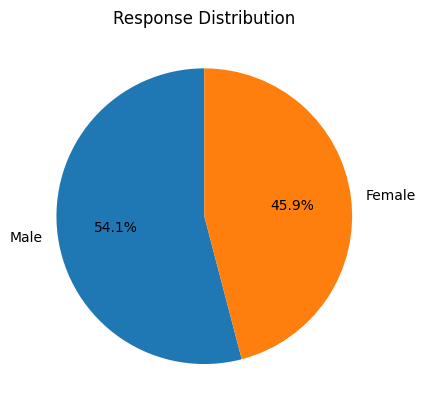

In [138]:
response_counts = train['Gender'].value_counts()

plt.pie(response_counts,
        labels=response_counts.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title("Response Distribution")
plt.show()

In [139]:
temp=train.groupby(['Gender'])['Driving_License'].count().to_frame().reset_index()

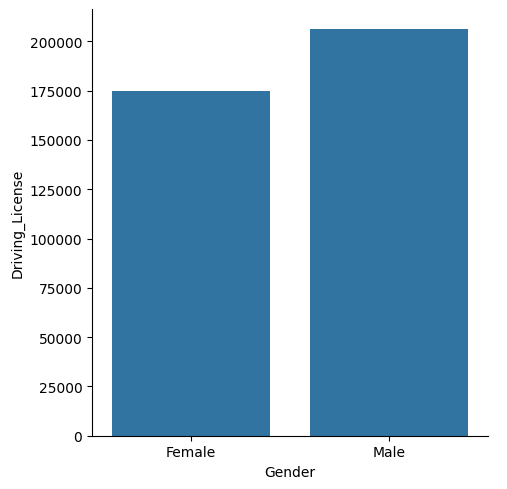

In [140]:
sns.catplot(x=temp['Gender'],y=temp['Driving_License'],kind='bar')

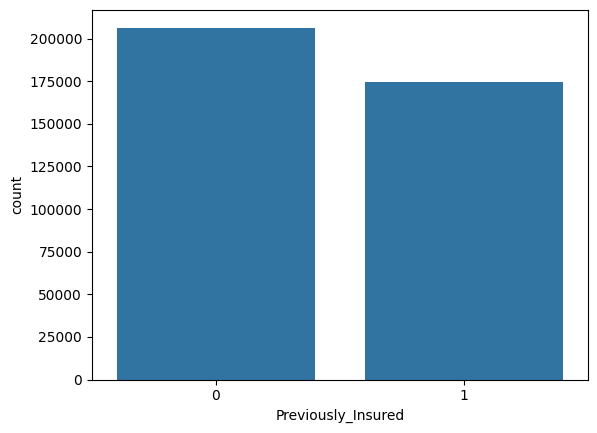

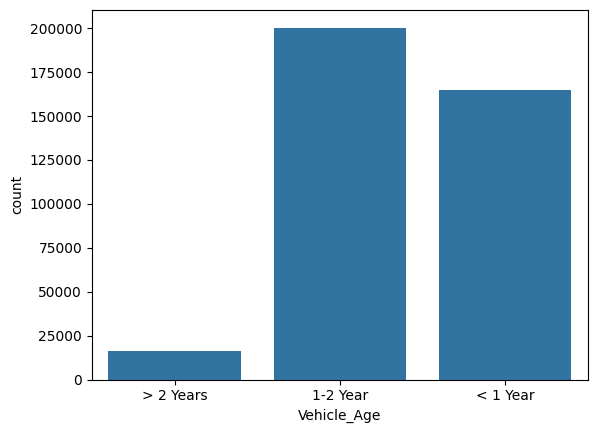

In [107]:
sns.countplot(x="Previously_Insured", data=train)
plt.show()

sns.countplot(x="Vehicle_Age", data=train)
plt.show()

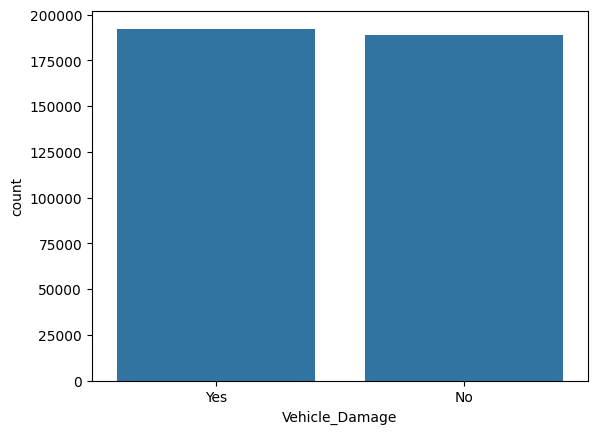

In [141]:
sns.countplot(x='Vehicle_Damage',data=train)
plt.show()

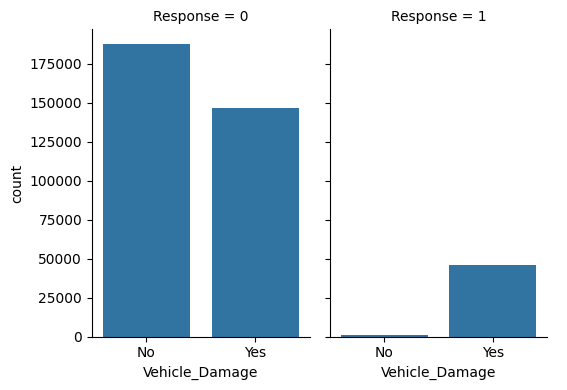

In [142]:
df=train.groupby(['Vehicle_Damage','Response'])['id'].count().to_frame().rename(columns={'id':'count'}).reset_index()
g = sns.catplot(x="Vehicle_Damage", y="count",col="Response",
                data=df, kind="bar",
                height=4, aspect=.7);

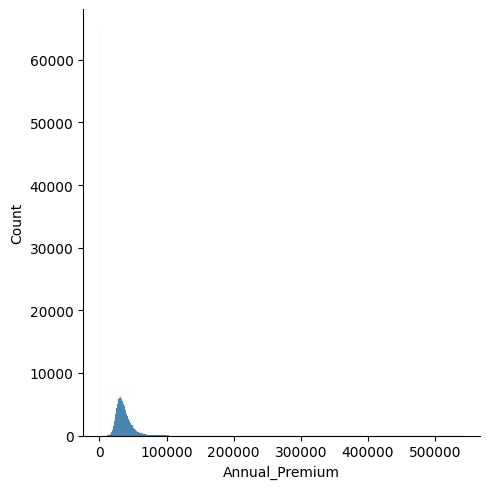

In [143]:
sns.displot(train.Annual_Premium)
plt.show()

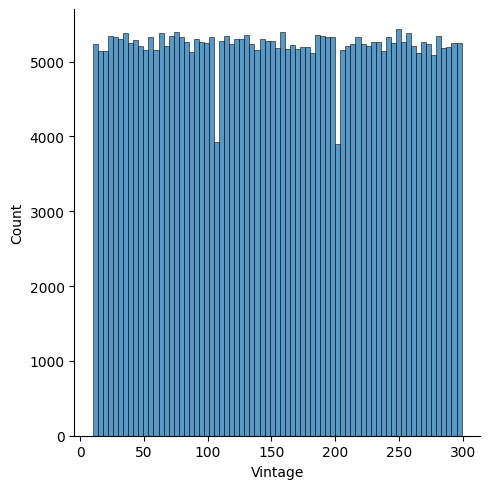

In [144]:
sns.displot(train.Vintage)

In [145]:
num_feat = ['Age','Vintage']
cat_feat = ['Gender', 'Driving_License', 'Previously_Insured', 'Vehicle_Age_lt_1_Year','Vehicle_Age_gt_2_Years','Vehicle_Damage_Yes','Region_Code','Policy_Sales_Channel']

In [146]:
train['Gender']=train.Gender.map({'Male':1,'Female':0}).astype(int)
print(train.head)

<bound method NDFrame.head of             id  Gender  Age  Driving_License  Region_Code  Previously_Insured  \
0            1       1   44                1         28.0                   0   
1            2       1   76                1          3.0                   0   
2            3       1   47                1         28.0                   0   
3            4       1   21                1         11.0                   1   
4            5       0   29                1         41.0                   1   
...        ...     ...  ...              ...          ...                 ...   
381104  381105       1   74                1         26.0                   1   
381105  381106       1   30                1         37.0                   1   
381106  381107       1   21                1         30.0                   1   
381107  381108       0   68                1         14.0                   0   
381108  381109       1   46                1         29.0                   0  

In [147]:
train['Vehicle_Damage']=train['Vehicle_Damage'].map({'Yes':1,'No':0}).astype(int)
print(train.head)

<bound method NDFrame.head of             id  Gender  Age  Driving_License  Region_Code  Previously_Insured  \
0            1       1   44                1         28.0                   0   
1            2       1   76                1          3.0                   0   
2            3       1   47                1         28.0                   0   
3            4       1   21                1         11.0                   1   
4            5       0   29                1         41.0                   1   
...        ...     ...  ...              ...          ...                 ...   
381104  381105       1   74                1         26.0                   1   
381105  381106       1   30                1         37.0                   1   
381106  381107       1   21                1         30.0                   1   
381107  381108       0   68                1         14.0                   0   
381108  381109       1   46                1         29.0                   0  

In [148]:

train = pd.get_dummies(
    train,
    columns=['Vehicle_Age'],
    prefix='Vehicle_Age',
    dtype=int
)
print(train.head())


   id  Gender  Age  Driving_License  Region_Code  Previously_Insured  \
0   1       1   44                1         28.0                   0   
1   2       1   76                1          3.0                   0   
2   3       1   47                1         28.0                   0   
3   4       1   21                1         11.0                   1   
4   5       0   29                1         41.0                   1   

   Vehicle_Damage  Annual_Premium  Policy_Sales_Channel  Vintage  Response  \
0               1         40454.0                  26.0      217         1   
1               0         33536.0                  26.0      183         0   
2               1         38294.0                  26.0       27         1   
3               0         28619.0                 152.0      203         0   
4               0         27496.0                 152.0       39         0   

   Vehicle_Age_1-2 Year  Vehicle_Age_< 1 Year  Vehicle_Age_> 2 Years  
0                     0    

In [150]:
from sklearn.preprocessing import MinMaxScaler,LabelEncoder,StandardScaler,RobustScaler
ss=StandardScaler()
mm=MinMaxScaler()

In [153]:
train[num_feat]=ss.fit_transform(train[num_feat])
train[['Annual_Premium']] = mm.fit_transform(train[['Annual_Premium']])

In [154]:
train.head

<bound method NDFrame.head of             id  Gender       Age  Driving_License  Region_Code  \
0            1       1  0.333777                1         28.0   
1            2       1  2.396751                1          3.0   
2            3       1  0.527181                1         28.0   
3            4       1 -1.148985                1         11.0   
4            5       0 -0.633242                1         41.0   
...        ...     ...       ...              ...          ...   
381104  381105       1  2.267815                1         26.0   
381105  381106       1 -0.568774                1         37.0   
381106  381107       1 -1.148985                1         30.0   
381107  381108       0  1.881007                1         14.0   
381108  381109       1  0.462713                1         29.0   

        Previously_Insured  Vehicle_Damage  Annual_Premium  \
0                        0               1        0.070366   
1                        0               0        0.0

In [160]:
train_target=train['Response']
train=train.drop(['Response'],axis=1)
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(train,train_target,random_state = 0)

In [161]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

random_search={
    'criterion': ['entropy', 'gini'],
               'max_depth': [2,3,4,5,6,7,10],
               'min_samples_leaf': [4, 6, 8],
               'min_samples_split': [5, 7,10],
               'n_estimators': [300]
}

In [163]:


rf=RandomForestClassifier()
model=RandomizedSearchCV(estimator=rf, param_distributions = random_search, n_iter = 10, 
                               cv = 4, verbose= 1, random_state= 101, n_jobs = -1)

model.fit(X_train,Y_train)

Fitting 4 folds for each of 10 candidates, totalling 40 fits


RandomizedSearchCV(cv=4, estimator=RandomForestClassifier(), n_jobs=-1,
                   param_distributions={'criterion': ['entropy', 'gini'],
                                        'max_depth': [2, 3, 4, 5, 6, 7, 10],
                                        'min_samples_leaf': [4, 6, 8],
                                        'min_samples_split': [5, 7, 10],
                                        'n_estimators': [300]},
                   random_state=101, verbose=1)

In [165]:
import pickle
filename = 'rf_model.sav'
pickle.dump(model, open(filename, 'wb'))

In [166]:
rf=pickle.load(open(filename, 'rb'))

In [167]:
from sklearn.metrics import f1_score, roc_auc_score,accuracy_score,confusion_matrix, precision_recall_curve, auc, roc_curve, recall_score, classification_report 

In [169]:
Y_pred=model.predict(X_test)


In [171]:
print (classification_report(Y_test, Y_pred))


              precision    recall  f1-score   support

           0       0.88      1.00      0.93     83603
           1       0.00      0.00      0.00     11675

    accuracy                           0.88     95278
   macro avg       0.44      0.50      0.47     95278
weighted avg       0.77      0.88      0.82     95278



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [174]:
Y_score = model.predict_proba(X_test)[:,1]
print (roc_auc_score(Y_test, Y_score))

0.8542971709287503
